In [17]:
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import HTML, display
import numpy as np

display(HTML("""
<style>
body.vscode-dark .xr-wrap,
body.vscode-high-contrast .xr-wrap {
    --xr-font-color0: #f0f3f6;
    --xr-font-color2: #c9d1d9;
    --xr-font-color3: #9da7b3;
    --xr-border-color: #6e7781;
    --xr-disabled-color: #9da7b3;
    --xr-background-color: #161b22;
    --xr-background-color-row-even: #21262d;
    --xr-background-color-row-odd: #30363d;
    color: var(--xr-font-color0);
}
</style>
"""))

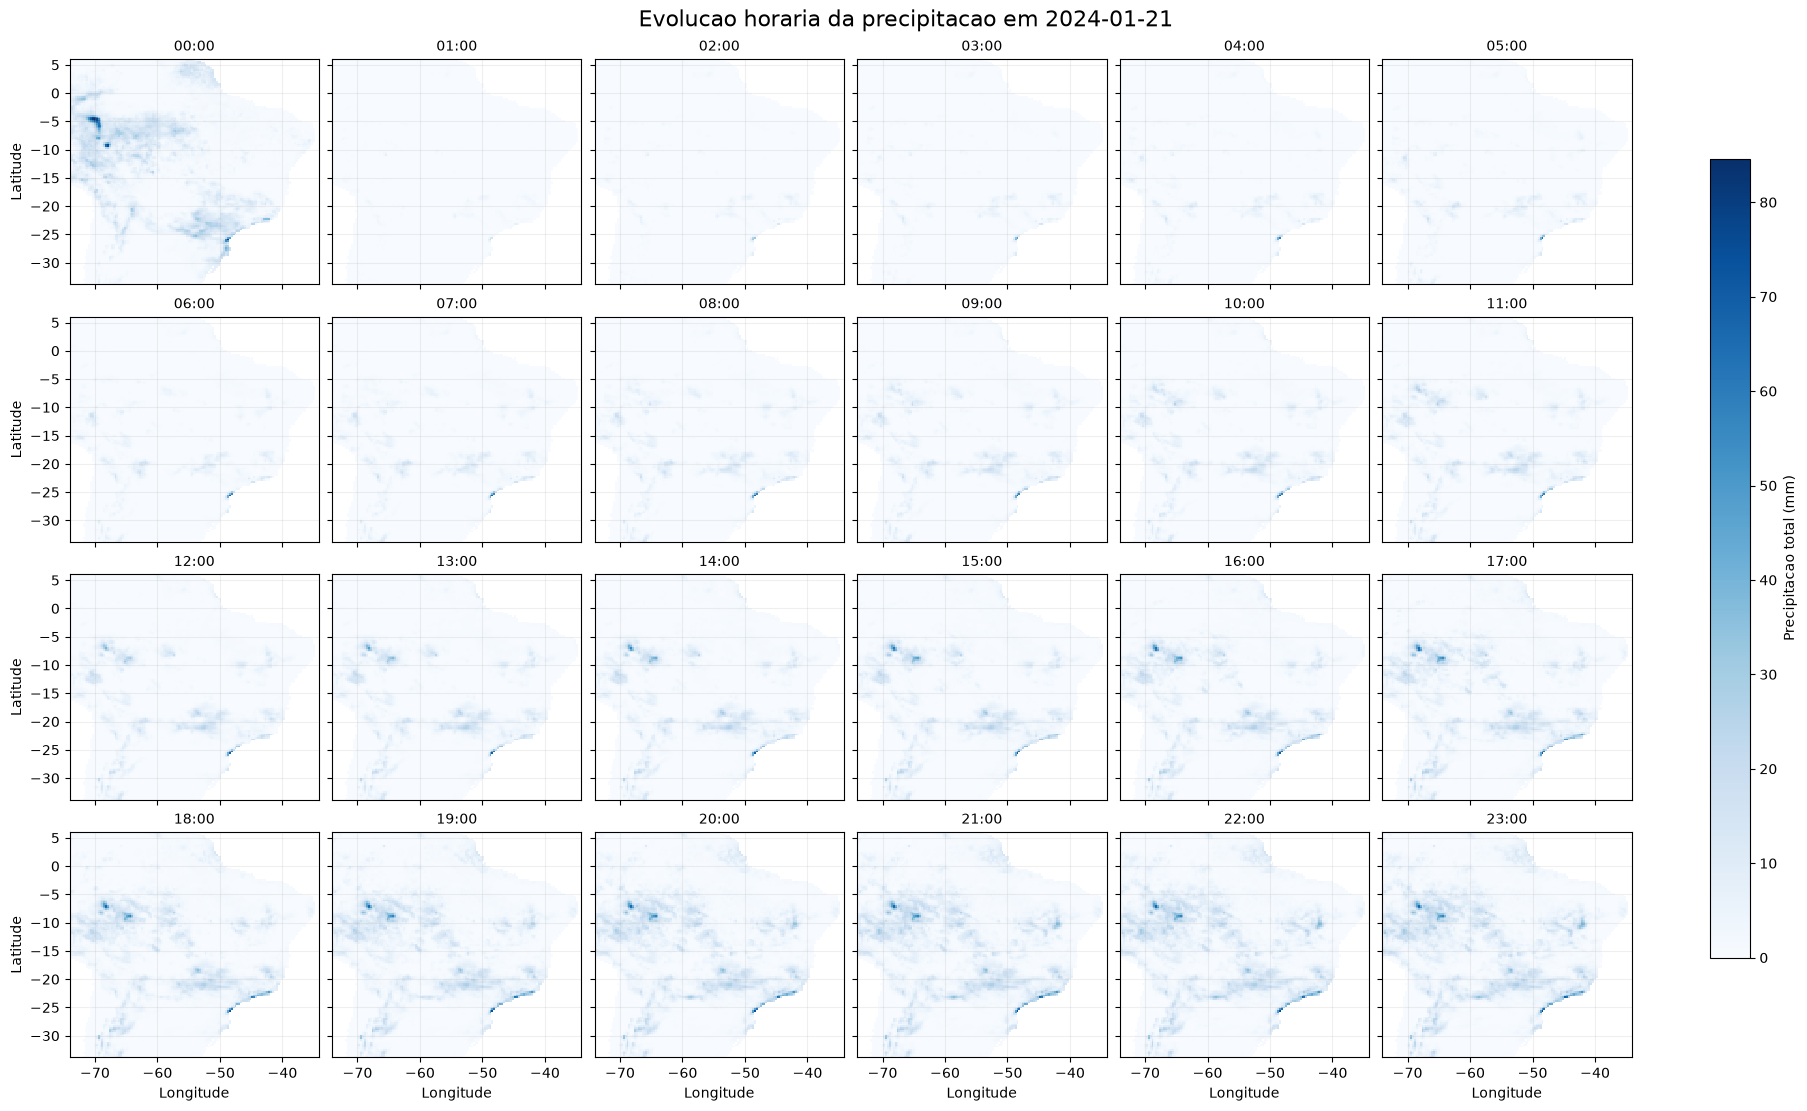

In [20]:
ds = xr.open_dataset("../data/processed/meteoro-coarsened/tp.nc")

# Escolhe aleatoriamente um dia que tenha 24 passos horarios completos.
times = ds.time.values
days, samples_per_day = np.unique(times.astype("datetime64[D]"), return_counts=True)
complete_days = days[samples_per_day == 24]
selected_day = np.random.default_rng().choice(complete_days)

precipitation_day = (
    ds["tp"]
    .sel(time=ds.time.dt.floor("D") == selected_day)
    .sortby("latitude")
    * 1_000
)
maximum_mm = float(precipitation_day.max(skipna=True))
color_maximum = maximum_mm if maximum_mm > 0 else 1.0

fig, axes = plt.subplots(
    4,
    6,
    figsize=(18, 11),
    sharex=True,
    sharey=True,
    layout="constrained",
)
for axis, time_index in zip(axes.flat, range(precipitation_day.sizes["time"])):
    precipitation_step = precipitation_day.isel(time=time_index)
    map_plot = precipitation_step.plot.pcolormesh(
        ax=axis,
        x="longitude",
        y="latitude",
        cmap="Blues",
        vmin=0,
        vmax=color_maximum,
        add_colorbar=False,
    )
    hour = np.datetime_as_string(precipitation_step.time.values, unit="h")[-2:]
    axis.set_title(f"{hour}:00", fontsize=10)
    axis.set_xlabel("")
    axis.set_ylabel("")
    axis.grid(alpha=0.2)

for axis in axes[-1, :]:
    axis.set_xlabel("Longitude")
for axis in axes[:, 0]:
    axis.set_ylabel("Latitude")

fig.colorbar(map_plot, ax=axes, label="Precipitacao total (mm)", shrink=0.8)
fig.suptitle(
    f"Evolucao horaria da precipitacao em {np.datetime_as_string(selected_day, unit='D')}",
    fontsize=16,
)
plt.show()

In [3]:
ds = xr.open_dataset(
    '../data/raw/era5/era5_hourly_2023_10.grib',
    engine="cfgrib", 
    backend_kwargs={"indexpath": ""})
ds

<xarray.Dataset> Size: 231MB
Dimensions:     (time: 744, latitude: 161, longitude: 161)
Coordinates:
  * time        (time) datetime64[ns] 6kB 2023-10-01 ... 2023-10-31T23:00:00
    valid_time  (time) datetime64[ns] 6kB ...
  * latitude    (latitude) float64 1kB 6.0 5.75 5.5 5.25 ... -33.5 -33.75 -34.0
  * longitude   (longitude) float64 1kB -74.0 -73.75 -73.5 ... -34.25 -34.0
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
Data variables:
    u100        (time, latitude, longitude) float32 77MB ...
    v100        (time, latitude, longitude) float32 77MB ...
    tcc         (time, latitude, longitude) float32 77MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-20T11:44 GRIB to CDM+CF via cfgrib-0.9.1...

In [5]:
ds = xr.open_dataset(
    '../data/raw/era5-land/era5_land_hourly_2023_10.grib',
    engine="cfgrib", 
    backend_kwargs={"indexpath": ""})
ds

<xarray.Dataset> Size: 2GB
Dimensions:     (time: 32, step: 24, latitude: 401, longitude: 401)
Coordinates:
  * time        (time) datetime64[ns] 256B 2023-09-30 2023-10-01 ... 2023-10-31
  * step        (step) timedelta64[ns] 192B 01:00:00 ... 1 days 00:00:00
    valid_time  (time, step) datetime64[ns] 6kB ...
  * latitude    (latitude) float64 3kB 6.0 5.9 5.8 5.7 ... -33.8 -33.9 -34.0
  * longitude   (longitude) float64 3kB -74.0 -73.9 -73.8 ... -34.2 -34.1 -34.0
    number      int64 8B ...
    surface     float64 8B ...
Data variables:
    t2m         (time, step, latitude, longitude) float32 494MB ...
    tp          (time, step, latitude, longitude) float32 494MB ...
    sp          (time, step, latitude, longitude) float32 494MB ...
    ssr         (time, step, latitude, longitude) float32 494MB ...
    str         (time, step, latitude, longitude) float32 494MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-20T11:45 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
ds = xr.open_dataset(
    '../data/processed/meteoro/',
    engine="cfgrib", 
    backend_kwargs={"indexpath": ""})
ds